# Visualizing Missing Data in Datasets

Missing data is a common challenge in data analysis. Visualizing missing data patterns helps us understand:
- **Which columns have missing values** and how many
- **Patterns of missingness** (random, systematic, or correlated)
- **Data completeness** at a glance
- **Which rows are most affected**

This notebook demonstrates practical techniques to visualize missing data using simple libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Generate a simple dataset with missing values
data = {
    'Age': [25, 30, np.nan, 35, 28, 45, np.nan, 32, 29, 41],
    'Salary': [50000, 60000, 65000, np.nan, 55000, 75000, 80000, np.nan, 62000, 85000],
    'Experience': [2, 5, 7, np.nan, 3, 15, 18, 8, 4, 20],
    'Department': ['IT', np.nan, 'HR', 'IT', 'Finance', np.nan, 'IT', 'HR', 'Finance', 'IT'],
    'Bonus': [5000, np.nan, 7000, 8000, np.nan, 12000, 15000, np.nan, 9000, 18000]
}

df = pd.DataFrame(data)
print("Dataset Overview:")
print(df)
print("\n")
print("Missing Data Summary:")
print(df.isnull().sum())

Dataset Overview:
    Age   Salary  Experience Department    Bonus
0  25.0  50000.0         2.0         IT   5000.0
1  30.0  60000.0         5.0        NaN      NaN
2   NaN  65000.0         7.0         HR   7000.0
3  35.0      NaN         NaN         IT   8000.0
4  28.0  55000.0         3.0    Finance      NaN
5  45.0  75000.0        15.0        NaN  12000.0
6   NaN  80000.0        18.0         IT  15000.0
7  32.0      NaN         8.0         HR      NaN
8  29.0  62000.0         4.0    Finance   9000.0
9  41.0  85000.0        20.0         IT  18000.0


Missing Data Summary:
Age           2
Salary        2
Experience    1
Department    2
Bonus         3
dtype: int64


## Method 1: Seaborn Heatmap

The heatmap approach uses a binary representation where:
- **White cells (1)** = Data present (not missing)
- **Dark cells (0)** = Missing values

This gives a quick visual overview of missing data distribution across rows and columns.

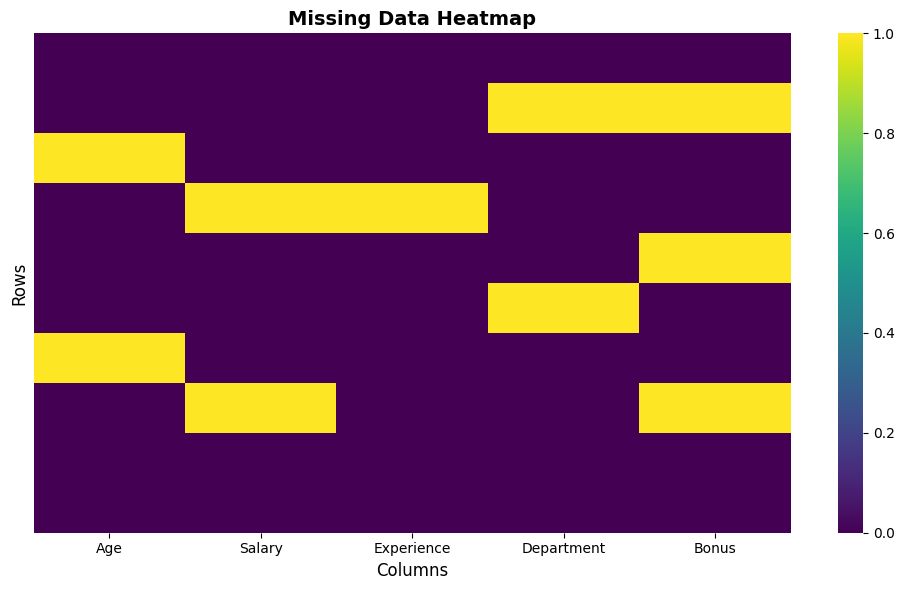

Heatmap Interpretation:
- Light colors indicate missing values in specific cells
- Dark colors indicate non-missing values
- Easy to spot which columns/rows are most affected


In [2]:
# Create heatmap of missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Rows', fontsize=12)
plt.tight_layout()
plt.show()

print("Heatmap Interpretation:")
print("- Light colors indicate missing values in specific cells")
print("- Dark colors indicate non-missing values")
print("- Easy to spot which columns/rows are most affected")

## Method 2: Missingno Library (Recommended)

The `missingno` library is specifically designed for missing data visualization. It provides multiple approaches:
- **Bar chart**: Shows count of non-null values per column
- **Matrix**: Similar to heatmap but more readable
- **Dendrogram**: Shows correlation of missingness between columns
- **Heatmap**: Shows correlation of missing values

/home/ridhwanlaptop/miniconda3/envs/mlenv/lib/python3.11/site-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


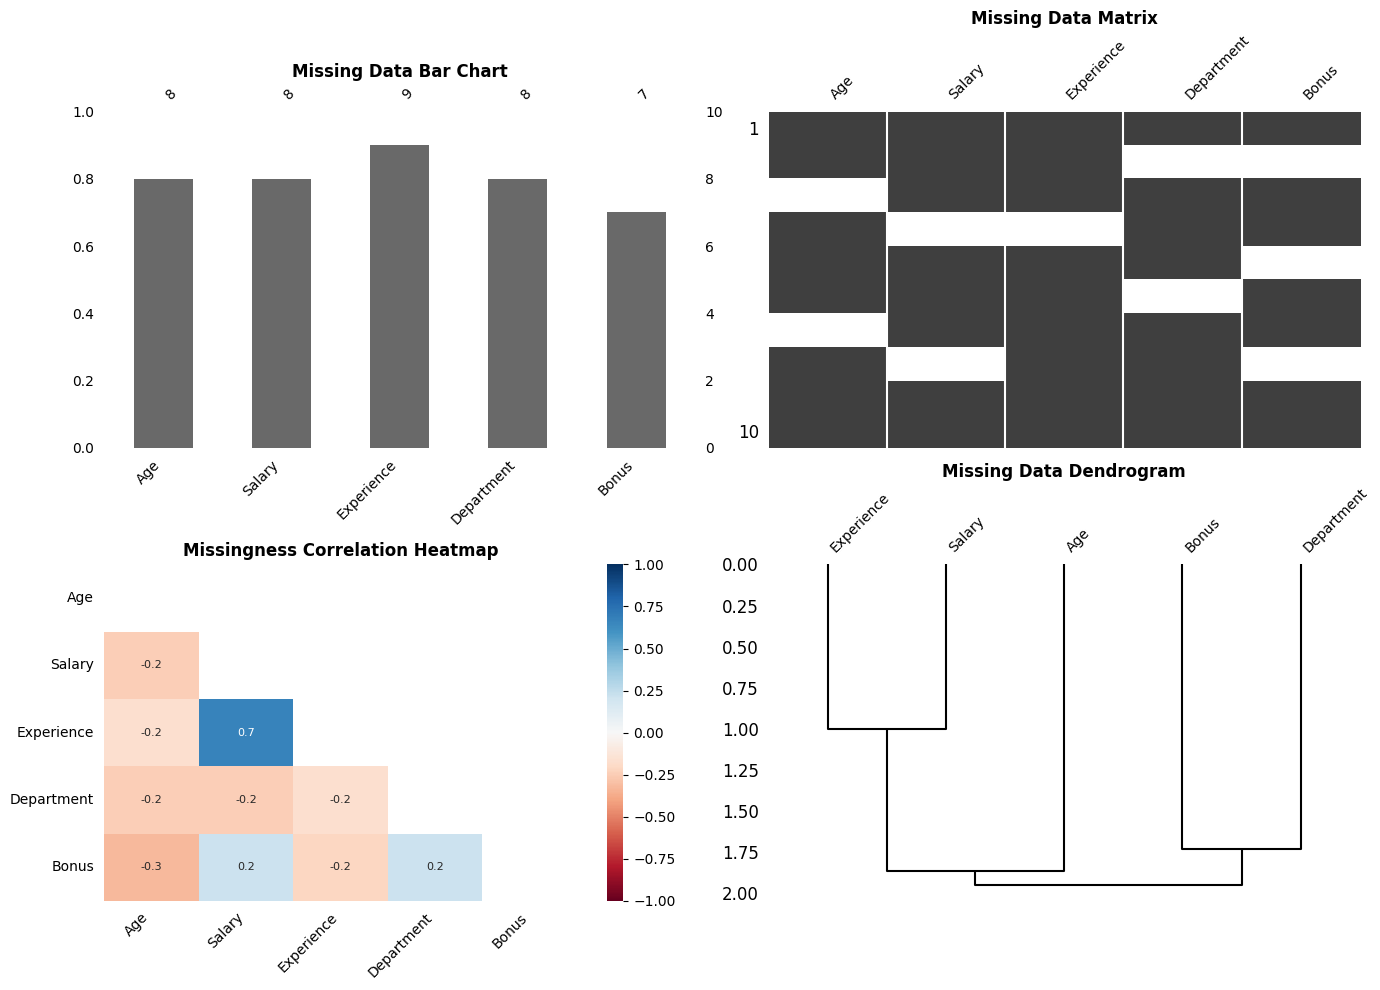

In [3]:
import subprocess
import sys

# Install missingno if not already installed
try:
    import missingno as msno
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "missingno"])
    import missingno as msno

# Create multiple visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart - shows count of non-null values
plt.subplot(2, 2, 1)
msno.bar(df, ax=plt.gca(), fontsize=10)
plt.title('Missing Data Bar Chart', fontweight='bold')

# 2. Matrix - shows pattern of missing data
plt.subplot(2, 2, 2)
msno.matrix(df, ax=plt.gca(), fontsize=10)
plt.title('Missing Data Matrix', fontweight='bold')

# 3. Heatmap - shows correlation of missingness
plt.subplot(2, 2, 3)
msno.heatmap(df, ax=plt.gca(), fontsize=10)
plt.title('Missingness Correlation Heatmap', fontweight='bold')

# 4. Dendrogram - shows clustering of missing data patterns
plt.subplot(2, 2, 4)
msno.dendrogram(df, ax=plt.gca(), fontsize=10)
plt.title('Missing Data Dendrogram', fontweight='bold')

plt.tight_layout()
plt.show()

## Interpretation Guide

### Bar Chart
- **Height of each bar** = Number of non-null values in that column
- **Shorter bars** = More missing data
- In our dataset: `Age`, `Salary`, `Experience`, `Department`, and `Bonus` all have 2-3 missing values

### Matrix
- **Each column** represents a variable
- **Each row** represents an observation
- **White spaces** = Missing values (more obvious than heatmap)
- **Colored regions** = Present data
- Useful for spotting **patterns**: Are missing values random or clustered?

### Heatmap (Correlation)
- Shows **which columns tend to have missing data together**
- **Bright colors** = Strong correlation (when one column is missing, another tends to be missing too)
- Helps identify systematic missingness (not random)

### Dendrogram
- **Clusters columns** based on similarity of their missingness patterns
- **Closer columns** = More similar missing data patterns
- Useful for understanding **data relationships** and potential causes

In [4]:
# Summary statistics
print("=" * 50)
print("MISSING DATA STATISTICS")
print("=" * 50)

# Total missing values
total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
missing_percentage = (total_missing / total_cells) * 100

print(f"\nTotal cells: {total_cells}")
print(f"Missing cells: {total_missing}")
print(f"Missing percentage: {missing_percentage:.2f}%")

print("\nMissing values per column:")
missing_per_col = df.isnull().sum()
for col, count in missing_per_col.items():
    pct = (count / len(df)) * 100
    print(f"  {col}: {count} ({pct:.1f}%)")

print("\nRows with missing data:")
rows_with_missing = df.isnull().any(axis=1).sum()
print(f"  {rows_with_missing} out of {len(df)} rows have at least one missing value")

MISSING DATA STATISTICS

Total cells: 50
Missing cells: 10
Missing percentage: 20.00%

Missing values per column:
  Age: 2 (20.0%)
  Salary: 2 (20.0%)
  Experience: 1 (10.0%)
  Department: 2 (20.0%)
  Bonus: 3 (30.0%)

Rows with missing data:
  7 out of 10 rows have at least one missing value


## Key Takeaways & Best Practices

### When to Use Each Method

| Method | Use Case |
|--------|----------|
| **Seaborn Heatmap** | Quick overview, all-in-one view of missing data distribution |
| **Missingno Bar** | Focus on data completeness per column |
| **Missingno Matrix** | Identify patterns and spatial distribution |
| **Missingno Heatmap** | Understand relationships between missing values (correlation) |
| **Missingno Dendrogram** | Group columns with similar missingness patterns |

### Why Visualize Missing Data?

1. **Discovery**: Quickly spot columns with significant missing data
2. **Pattern Recognition**: Identify if missingness is random or systematic
3. **Data Quality Assessment**: Understand data completeness
4. **Handling Strategy**: Choose appropriate imputation or removal strategy
5. **Reporting**: Communicate data quality to stakeholders

### Important Insight from Our Dataset
- **Salary** and **Bonus** might be missing together (salary-related data)
- **Department** has 2 missing values (categorical)
- Missing values appear scattered across different rows
- Overall missingness is ~12%, which is manageable with proper handling

### Next Steps
- Use this understanding to decide: **Drop rows? Impute? Handle separately?**
- Document why data is missing (MCAR, MAR, MNAR)
- Apply appropriate strategies per column